<a href="https://colab.research.google.com/github/ebritolbv-cmd/BrazilQuantumCamp/blob/main/3_code_extra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brazil Quantum Camp
## Material extra
**Bloco 2, aula 3** - Algoritmos quânticos - parte 2

In [ ]:
!pip install qiskit qiskit-aer pylatexenc -q

from math import pi, log2, gcd
from fractions import Fraction
from random import randint
import pylatexenc

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

## Transformada Quântica de Fourier (QFT)

A *Transformada Quântica de Fourier (QFT)* é crucial para algoritmos como o de Shor. Ela mapeia estados da *codificação de base computacional* para um domínio de *frequência*, onde a informação é codificada nas *fases relativas* dos qubits.

Para $n$ qubits ($N = 2^n$), a QFT é definida por:

$$\text{QFT}\left|x\right> = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i x k / N} \left|k\right>$$

A seguir, construiremos e aplicaremos a QFT no Qiskit.

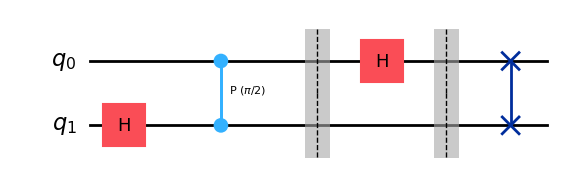

In [ ]:
def draw(qc, fold=None): #fold controla a quebra de linha do circuito
    return qc.draw("mpl", fold=fold, plot_barriers=True)


def qft(qc, qubits, do_swaps: bool = True):
    for j in range(len(qubits) - 1, -1, -1): #Percorre os qubits de trás para frente
        qc.h(qubits[j])
        for k in range(j - 1, -1, -1):
            qc.cp(pi / 2 ** (j - k), qubits[k], qubits[j])
        qc.barrier()

    if do_swaps:
        size = len(qubits)
        for i in range(size // 2):
            qc.swap(qubits[i], qubits[size - i - 1])


def iqft(qc, qubits, do_swaps: bool = True):
    tmp = QuantumCircuit(len(qubits))
    qft(tmp, list(range(len(qubits))), do_swaps=do_swaps)
    qc.compose(tmp.inverse(), qubits, inplace=True)


n = 2
qc_draw = QuantumCircuit(n)
qft(qc_draw, list(range(n)))

draw(qc_draw, fold=-1)


In [ ]:
qc = QuantumCircuit(n)
qc.x(range(n))

Statevector.from_instruction(qc).draw('latex')

<IPython.core.display.Latex object>

In [ ]:
qft(qc, list(range(n)))

Statevector.from_instruction(qc).draw('latex')

<IPython.core.display.Latex object>

In [ ]:
qc.z(0)

Statevector.from_instruction(qc).draw('latex')

<IPython.core.display.Latex object>

In [ ]:
iqft(qc, list(range(n)))

Statevector.from_instruction(qc).draw('latex')

<IPython.core.display.Latex object>

### Algoritmo de Estimação de Fase

O *Algoritmo de Estimação de Fase (QPE - Quantum Phase Estimation)* é uma das ferramentas mais poderosas da computação quântica, servindo como um pilar para muitos outros algoritmos complexos, incluindo o já mencionado *Algoritmo de Shor*.

Seu objetivo principal é *estimar a fase* $\phi$ de um autovalor $e^{i2\pi\phi}$ associado a um operador unitário $U$, dado um autoestado $\left|\psi\right>$ desse operador, tal que $U\left|\psi\right> = e^{i2\pi\phi}\left|\psi\right>$. Em termos mais simples, ele nos permite *extrair informações de fase* codificadas em um estado quântico.

A beleza do QPE reside em sua capacidade de transformar uma fase em uma sequência de bits mensurável. Para isso, ele utiliza a *Transformada Quântica de Fourier Inversa (IQFT)*, que é a operação inversa da QFT que acabamos de explorar.

O algoritmo funciona em dois registradores quânticos: um para armazenar a estimativa da fase e outro para o autoestado. Através de uma sequência de portas Hadamard, portas controladas do operador $U$ e a aplicação final da IQFT, a fase é revelada na forma binária no primeiro registro.

![](https://upload.wikimedia.org/wikipedia/commons/a/a5/PhaseCircuit-crop.svg)

A seguir, vamos a implantação do Algoritmo de Estimação de Fase no Qiskit.

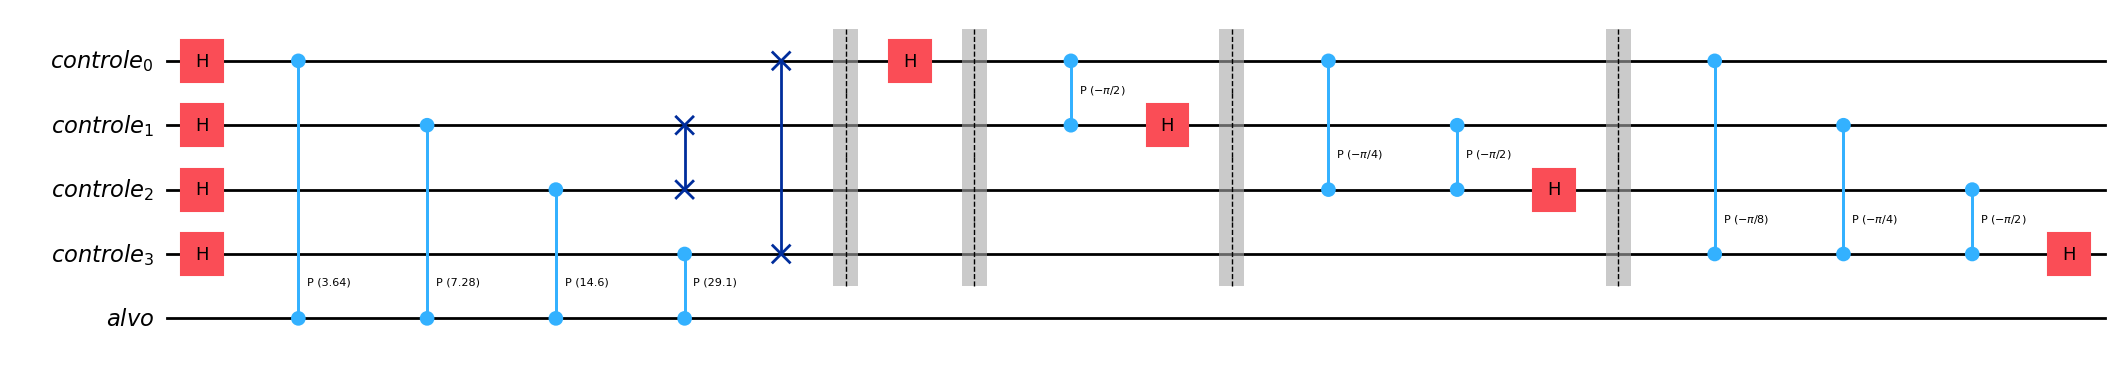

In [ ]:
def oracle_estima_fase(qc, i, controle, alvo, fase=0.5791015625):
    qc.cp(2 * pi * fase * 2**i, controle, alvo)


def estima_fase(qc, controle, alvo, fase=0.5791015625):
    qc.h(controle)

    for i, q in enumerate(controle):
        oracle_estima_fase(qc, i, q, alvo, fase=fase)

    iqft(qc, controle)

controle = QuantumRegister(4, "controle")
alvo = QuantumRegister(1, "alvo")
qc_draw = QuantumCircuit(controle, alvo)
estima_fase(qc_draw, controle, alvo[0])

draw(qc_draw, fold=-1)


In [ ]:
p = 0.5791015625
n_controle = 10

controle = QuantumRegister(n_controle, "controle")
alvo = QuantumRegister(1, "alvo")
c = ClassicalRegister(n_controle, "c")

qc = QuantumCircuit(controle, alvo, c)
qc.x(alvo[0])

estima_fase(qc, controle, alvo[0], fase=p)
qc.measure(controle, c)

sim = AerSimulator()
result = sim.run(qc, shots=2048).result()
resultado = int(max(result.get_counts().items(), key=lambda kv: kv[1])[0], 2)

print("Resultado:", resultado)
print("Pós-processamento:", resultado / 2 ** n_controle)

Resultado: 593
Pós-processamento: 0.5791015625


### Algoritmo de Shor

O *Algoritmo de Shor* resolve o problema da fatoração de números inteiros. Dado um número inteiro composto, ele encontra um de seus fatores não triviais de forma eficiente.

Esse problema é de grande interesse para a área de segurança da informação, pois a segurança de algoritmos de criptografia assimétrica, como o RSA, depende da dificuldade de fatorar grandes números. O algoritmo de Shor representa uma ameaça a esses sistemas, pois pode quebrar chaves criptográficas que, com os métodos clássicos, levariam milhares de anos para serem descobertas.


![](https://upload.wikimedia.org/wikipedia/commons/6/6b/Shor%27s_algorithm.svg)

Esse algoritmo funciona ao reduzir o problema da fatoração à encontrar o período de uma função associada ao número a ser fatorado. Para isso, ele utiliza uma sub-rotina quântica difícil de realizar em computadores clássicos, mas eficiente em computadores quânticos.

In [ ]:
def qu_exp(qc, a: int, x, n: int, y):
    for state in range(2 ** len(x)):
        # Prepara controles para o estado |state>
        for i, q in enumerate(x):
            if ((state >> i) & 1) == 0:
                qc.x(q)

        # Define y = a^state mod n quando x == state
        y_val = pow(a, state, n)
        for i, q in enumerate(y):
            if (y_val >> i) & 1:
                qc.mcx(x, q)

        # Desfaz preparação
        for i, q in enumerate(x):
            if ((state >> i) & 1) == 0:
                qc.x(q)


def shor_quantico(a: int, N: int, shots: int = 1024):
    n = N.bit_length()

    x = QuantumRegister(n, "x")
    y = QuantumRegister(n, "y")
    cx = ClassicalRegister(n, "cx")
    cy = ClassicalRegister(n, "cy")
    qc = QuantumCircuit(x, y, cx, cy)

    qc.h(x)
    qu_exp(qc, a, x, N, y)
    qc.measure(y, cy)
    iqft(qc, list(reversed(x)))
    qc.measure(x, cx)

    sim = AerSimulator()
    counts = sim.run(qc, shots=shots).result().get_counts()

    most = max(counts, key=counts.get)
    # A string de contagens vem como "cy cx" porque cx foi declarado antes de cy
    x_bits = most.split(" ")[1]
    r = Fraction(int(x_bits, 2) / 2**n).denominator

    return r


In [ ]:
def shor(N):
    # Se N for par, retorna o fator 2.
    if N % 2 == 0:
        return 2

    # Se N = a^b para inteiros a >= 1 e b >= 2, retorna a.
    n = N.bit_length()
    y = int(log2(N))
    for b in range(2, n + 1):
        x = y / b
        u1 = int(2**x)
        u2 = u1 + 1

        if u1**b == N:
            return u1
        elif u2**b == N:
            return u2

    # Escolhe a aleatoriamente. Se mdc(a, N) > 1 retorna mdc(a, N).
    for _ in range(n):
        a = randint(2, N - 1)
        mdc_a_N = gcd(a, N)
        if mdc_a_N > 1:
            print("sorte!")
            return mdc_a_N

        # Encontrando a ordem com algoritmo quântico
        r = shor_quantico(a, N)

        if r % 2 == 0 and pow(a, r // 2, N) != N - 1:
            p = gcd(a ** (r // 2) - 1, N)
            if p != 1 and p * N // p == N:
                return p

            q = gcd(a ** (r // 2) + 1, N)
            if q != 1 and q * N // q == N:
                return q

    raise RuntimeError("Falha ao fatorar, tente novamente")

In [ ]:
N = 7*19
a = shor(N)
print(f"{a} x {N//a} = {N}")

7 x 19 = 133
